# Unidad 5 · Bloque 4: Autoencoders
**Métodos de Análisis de Datos I — UNS**

---

## Contenido
1. Arquitectura del autoencoder
2. Autoencoder lineal vs PCA
3. Autoencoder no lineal: reducción de dimensionalidad
4. Detección de anomalías con autoencoders
5. Denoising autoencoder

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, make_blobs
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Verificar disponibilidad de TensorFlow/Keras
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    tf.random.set_seed(42)
    np.random.seed(42)
    print(f'TensorFlow {tf.__version__} disponible.')
    TF_DISPONIBLE = True
except ImportError:
    print('TensorFlow no disponible. Instalar con: pip install tensorflow')
    print('Las celdas de entrenamiento mostrarán el código pero no ejecutarán.')
    TF_DISPONIBLE = False

TensorFlow no disponible. Instalar con: pip install tensorflow
Las celdas de entrenamiento mostrarán el código pero no ejecutarán.


---
## 1. Arquitectura del autoencoder

### Definiciones clave

> **Autoencoder:** red neuronal con arquitectura encoder–bottleneck–decoder entrenada para minimizar el error de reconstrucción:
> $$\mathcal{L} = \frac{1}{n}\sum_{i=1}^n \|\mathbf{x}_i - \hat{\mathbf{x}}_i\|^2, \quad \hat{\mathbf{x}}_i = \text{decoder}(\text{encoder}(\mathbf{x}_i))$$
> No requiere etiquetas: la señal de aprendizaje es el propio dato de entrada.

> **Encoder:** transforma la entrada $\mathbf{x} \in \mathbb{R}^p$ en una representación comprimida $\mathbf{z} \in \mathbb{R}^q$ con $q \ll p$.

> **Bottleneck (cuello de botella):** la capa de menor dimensión $q$. Es la representación latente: el "resumen" de los datos.

> **Decoder:** reconstruye $\hat{\mathbf{x}} \in \mathbb{R}^p$ a partir de $\mathbf{z}$. Tiene arquitectura espejo del encoder.

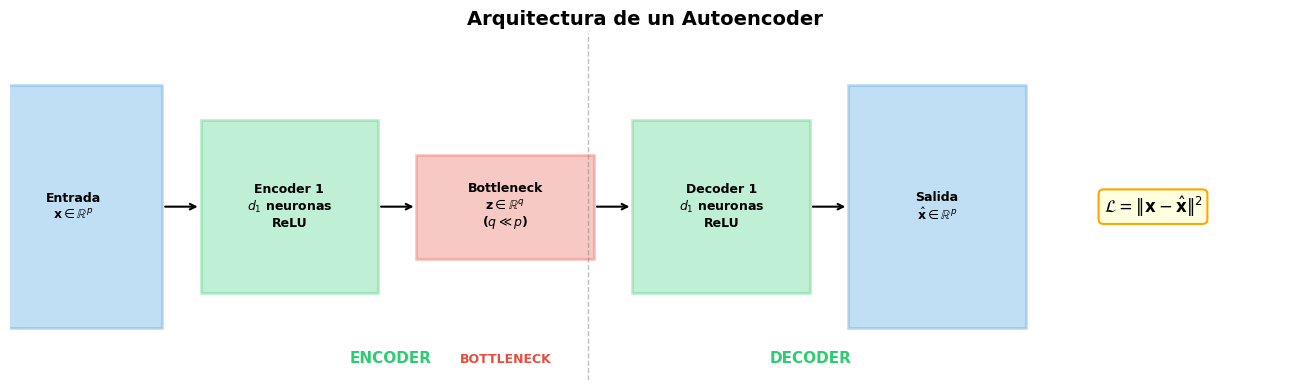

In [2]:
# Diagrama conceptual de la arquitectura
fig, ax = plt.subplots(figsize=(13, 4))
ax.axis('off')

capas = [
    (0.05, 0.7, 'Entrada\n$\\mathbf{x} \\in \\mathbb{R}^p$', '#3498DB'),
    (0.22, 0.5, 'Encoder 1\n$d_1$ neuronas\nReLU', '#2ECC71'),
    (0.39, 0.3, 'Bottleneck\n$\\mathbf{z} \\in \\mathbb{R}^q$\n($q \\ll p$)', '#E74C3C'),
    (0.56, 0.5, 'Decoder 1\n$d_1$ neuronas\nReLU', '#2ECC71'),
    (0.73, 0.7, 'Salida\n$\\hat{\\mathbf{x}} \\in \\mathbb{R}^p$', '#3498DB'),
]

for x, alto, texto, color in capas:
    rect = plt.Rectangle((x - 0.07, 0.5 - alto/2), 0.14, alto,
                          facecolor=color, alpha=0.3, edgecolor=color, lw=2)
    ax.add_patch(rect)
    ax.text(x, 0.5, texto, ha='center', va='center', fontsize=9, fontweight='bold')

# Flechas
for i in range(len(capas) - 1):
    x1, x2 = capas[i][0] + 0.07, capas[i+1][0] - 0.07
    ax.annotate('', xy=(x2, 0.5), xytext=(x1, 0.5),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# Etiquetas
ax.text(0.30, 0.05, 'ENCODER', ha='center', fontsize=11, color='#2ECC71', fontweight='bold')
ax.text(0.63, 0.05, 'DECODER', ha='center', fontsize=11, color='#2ECC71', fontweight='bold')
ax.text(0.39, 0.05, 'BOTTLENECK', ha='center', fontsize=9, color='#E74C3C', fontweight='bold')
ax.axvline(0.455, color='gray', lw=1, linestyle='--', alpha=0.5)

# Pérdida
ax.text(0.90, 0.5, '$\\mathcal{L} = \\|\\mathbf{x} - \\hat{\\mathbf{x}}\\|^2$',
        ha='center', va='center', fontsize=12, color='black',
        bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='orange', lw=1.5))

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title('Arquitectura de un Autoencoder', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Autoencoder lineal vs PCA

### Definición clave

> **Equivalencia lineal:** un autoencoder sin funciones de activación no lineales y con una sola capa oculta es matemáticamente equivalente a PCA: aprende el mismo subespacio. Lo que diferencia realmente a los autoencoders es el uso de activaciones no lineales (ReLU, sigmoid, tanh) en capas más profundas.

TensorFlow no disponible: mostrando solo PCA.


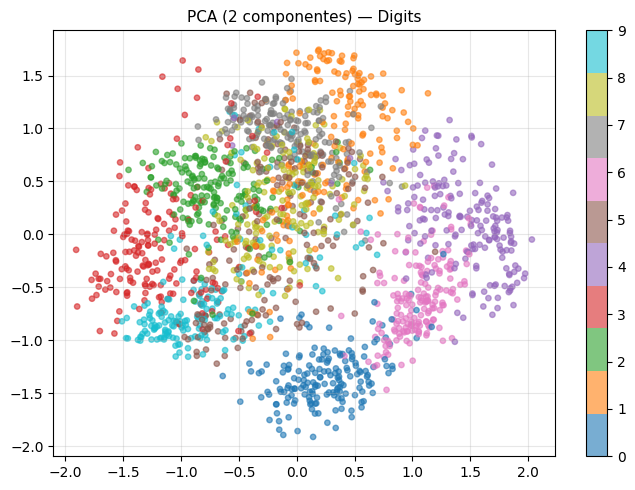

In [3]:
# Demostración de equivalencia: autoencoder lineal == PCA
digits = load_digits()
scaler = MinMaxScaler()
X_dig = scaler.fit_transform(digits.data)  # [0,1] para activación sigmoid
y_dig = digits.target

DIM_LATENTE = 2

if TF_DISPONIBLE:
    # Autoencoder LINEAL (sin activaciones en capa oculta)
    encoder_lin = keras.Sequential([
        layers.Dense(DIM_LATENTE, activation='linear', input_shape=(64,))
    ])
    decoder_lin = keras.Sequential([
        layers.Dense(64, activation='linear', input_shape=(DIM_LATENTE,))
    ])
    input_ae = keras.Input(shape=(64,))
    encoded  = encoder_lin(input_ae)
    decoded  = decoder_lin(encoded)
    ae_lineal = keras.Model(input_ae, decoded)
    ae_lineal.compile(optimizer='adam', loss='mse')

    hist_lin = ae_lineal.fit(X_dig, X_dig, epochs=200, batch_size=64,
                             validation_split=0.1, verbose=0)
    z_ae_lin = encoder_lin.predict(X_dig, verbose=0)
    print('Autoencoder lineal entrenado.')
else:
    print('TensorFlow no disponible: mostrando solo PCA.')

# PCA a 2 componentes
pca2 = PCA(n_components=2)
z_pca = pca2.fit_transform(MinMaxScaler().fit_transform(digits.data))

# Visualización
if TF_DISPONIBLE:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, z, titulo in zip(axes, [z_pca, z_ae_lin],
                              ['PCA (2 componentes)', 'Autoencoder lineal (2 dims)']):
        sc = ax.scatter(z[:, 0], z[:, 1], c=y_dig, cmap='tab10', alpha=0.6, s=15)
        ax.set_title(titulo, fontsize=11)
        plt.colorbar(sc, ax=ax)
        ax.grid(True, alpha=0.3)
    plt.suptitle('PCA vs Autoencoder lineal — Digits', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print('Ambos capturan la misma estructura. El AE lineal aprende el mismo subespacio que PCA.')
else:
    fig, ax = plt.subplots(figsize=(7, 5))
    sc = ax.scatter(z_pca[:, 0], z_pca[:, 1], c=y_dig, cmap='tab10', alpha=0.6, s=15)
    ax.set_title('PCA (2 componentes) — Digits', fontsize=11)
    plt.colorbar(sc, ax=ax)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

---
## 3. Autoencoder no lineal: reducción de dimensionalidad

### Definiciones clave

> **Autoencoder no lineal:** usa funciones de activación no lineales (ReLU, sigmoid) en las capas ocultas. Puede capturar estructuras no lineales que PCA no puede representar.

> **Error de reconstrucción:** $\|\mathbf{x} - \hat{\mathbf{x}}\|^2$. Si el AE no lineal tiene menor error de reconstrucción que PCA con la misma dimensión latente, está capturando estructura no lineal.

In [4]:
if TF_DISPONIBLE:
    # Autoencoder NO LINEAL
    # Encoder: 64 -> 32 -> 16 -> 2
    # Decoder: 2  -> 16 -> 32 -> 64
    input_ae2 = keras.Input(shape=(64,))
    x = layers.Dense(32, activation='relu')(input_ae2)
    x = layers.Dense(16, activation='relu')(x)
    z = layers.Dense(DIM_LATENTE, activation='linear', name='bottleneck')(x)
    x = layers.Dense(16, activation='relu')(z)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(64, activation='sigmoid')(x)

    ae_nolineal = keras.Model(input_ae2, out)
    encoder_nl  = keras.Model(input_ae2, z)

    ae_nolineal.compile(optimizer='adam', loss='mse')
    hist_nl = ae_nolineal.fit(X_dig, X_dig, epochs=200, batch_size=64,
                              validation_split=0.1, verbose=0)

    z_ae_nl = encoder_nl.predict(X_dig, verbose=0)
    X_rec_nl = ae_nolineal.predict(X_dig, verbose=0)
    X_rec_pca = pca2.inverse_transform(z_pca)

    mse_pca = np.mean((MinMaxScaler().fit_transform(digits.data) - X_rec_pca)**2)
    mse_nl  = np.mean((X_dig - X_rec_nl)**2)

    print(f'Error de reconstrucción (MSE):')
    print(f'  PCA (2 componentes):         {mse_pca:.5f}')
    print(f'  Autoencoder no lineal (2D):  {mse_nl:.5f}')

    # Comparar embeddings y curvas de entrenamiento
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, z, titulo in zip(axes[:2], [z_pca, z_ae_nl],
                               ['PCA', 'AE no lineal (2D)']):
        sc = ax.scatter(z[:, 0], z[:, 1], c=y_dig, cmap='tab10', alpha=0.6, s=15)
        ax.set_title(titulo, fontsize=11)
        plt.colorbar(sc, ax=ax)
        ax.grid(True, alpha=0.3)

    axes[2].plot(hist_nl.history['loss'], label='Train')
    axes[2].plot(hist_nl.history['val_loss'], label='Validación')
    axes[2].set_title('Curva de aprendizaje — AE no lineal', fontsize=11)
    axes[2].set_xlabel('Época'); axes[2].set_ylabel('MSE')
    axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.suptitle('Autoencoder no lineal vs PCA — Digits', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

else:
    print('Sin TensorFlow: el código del AE no lineal está definido pero no ejecuta.')
    print('''
# Arquitectura del AE no lineal (referencia):
input_ae2 = keras.Input(shape=(64,))
x = layers.Dense(32, activation="relu")(input_ae2)
x = layers.Dense(16, activation="relu")(x)
z = layers.Dense(2,  activation="linear", name="bottleneck")(x)
x = layers.Dense(16, activation="relu")(z)
x = layers.Dense(32, activation="relu")(x)
out = layers.Dense(64, activation="sigmoid")(x)
ae_nolineal = keras.Model(input_ae2, out)
ae_nolineal.compile(optimizer="adam", loss="mse")
ae_nolineal.fit(X_dig, X_dig, epochs=200, batch_size=64, validation_split=0.1)
    ''')

Sin TensorFlow: el código del AE no lineal está definido pero no ejecuta.

# Arquitectura del AE no lineal (referencia):
input_ae2 = keras.Input(shape=(64,))
x = layers.Dense(32, activation="relu")(input_ae2)
x = layers.Dense(16, activation="relu")(x)
z = layers.Dense(2,  activation="linear", name="bottleneck")(x)
x = layers.Dense(16, activation="relu")(z)
x = layers.Dense(32, activation="relu")(x)
out = layers.Dense(64, activation="sigmoid")(x)
ae_nolineal = keras.Model(input_ae2, out)
ae_nolineal.compile(optimizer="adam", loss="mse")
ae_nolineal.fit(X_dig, X_dig, epochs=200, batch_size=64, validation_split=0.1)
    


In [5]:
if TF_DISPONIBLE:
    # Visualizar reconstrucciones
    n_mostrar = 10
    idx_mostrar = np.random.choice(len(X_dig), n_mostrar, replace=False)

    fig, axes = plt.subplots(3, n_mostrar, figsize=(16, 4))
    titulos_filas = ['Original', f'PCA (MSE={mse_pca:.4f})', f'AE no lineal (MSE={mse_nl:.4f})']

    for col, idx in enumerate(idx_mostrar):
        for fila, (img, titulo) in enumerate(zip(
            [X_dig[idx], X_rec_pca[idx], X_rec_nl[idx]], titulos_filas)):
            axes[fila, col].imshow(img.reshape(8, 8), cmap='gray', vmin=0, vmax=1)
            axes[fila, col].axis('off')
            if col == 0:
                axes[fila, col].set_ylabel(titulo, fontsize=8, rotation=0,
                                           labelpad=60, va='center')

    plt.suptitle('Reconstrucciones: Original vs PCA vs AE no lineal — Digits',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 4. Detección de anomalías con autoencoders

### Definiciones clave

> **Principio:** entrenar el AE solo con datos normales. Un patrón no visto durante el entrenamiento (anomalía) será difícil de reconstruir → error de reconstrucción alto.

> **Score de anomalía:** $\text{score}(\mathbf{x}) = \|\mathbf{x} - \hat{\mathbf{x}}\|^2$.

> **Umbral $\tau$:** se fija mirando la distribución de errores en el conjunto de entrenamiento. Valor típico: percentil 95 o 99.

In [6]:
if TF_DISPONIBLE:
    # Simular detección de anomalías: entrenar con dígitos '0', detectar los demás
    mask_0 = y_dig == 0
    X_normal_ae = X_dig[mask_0]

    # AE entrenado solo con dígitos '0'
    inp_det = keras.Input(shape=(64,))
    h = layers.Dense(32, activation='relu')(inp_det)
    h = layers.Dense(8,  activation='relu')(h)
    h = layers.Dense(32, activation='relu')(h)
    out_det = layers.Dense(64, activation='sigmoid')(h)

    ae_det = keras.Model(inp_det, out_det)
    ae_det.compile(optimizer='adam', loss='mse')
    ae_det.fit(X_normal_ae, X_normal_ae, epochs=150, batch_size=16,
               validation_split=0.1, verbose=0)

    # Error de reconstrucción sobre todos los dígitos
    X_rec_det = ae_det.predict(X_dig, verbose=0)
    errores = np.mean((X_dig - X_rec_det)**2, axis=1)

    # Umbral: percentil 95 de los errores de los '0' de entrenamiento
    errores_train = np.mean((X_normal_ae - ae_det.predict(X_normal_ae, verbose=0))**2, axis=1)
    umbral = np.percentile(errores_train, 95)

    predicciones = (errores > umbral).astype(int)  # 1=anomalía, 0=normal
    anomalias_reales = (y_dig != 0).astype(int)

    from sklearn.metrics import roc_auc_score
    auc_ae = roc_auc_score(anomalias_reales, errores)
    print(f'AUC-ROC (AE detectando dígitos != 0): {auc_ae:.4f}')
    print(f'Umbral (percentil 95 de errores en entrenamiento): {umbral:.5f}')

    # Distribución de errores
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for digito in range(10):
        mask_d = y_dig == digito
        axes[0].scatter([digito]*mask_d.sum(),
                        errores[mask_d],
                        alpha=0.3, s=10,
                        c=['#2ECC71' if digito == 0 else '#E74C3C'])
    axes[0].axhline(umbral, color='black', linestyle='--', lw=2, label=f'Umbral={umbral:.4f}')
    axes[0].set_xlabel('Dígito'); axes[0].set_ylabel('Error de reconstrucción')
    axes[0].set_title('Error por clase (verde=normal, rojo=anomalía)', fontsize=10)
    axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)
    axes[0].set_xticks(range(10))

    axes[1].hist(errores[y_dig == 0],  bins=30, alpha=0.6, color='#2ECC71', label='Dígito 0 (normal)')
    axes[1].hist(errores[y_dig != 0],  bins=30, alpha=0.4, color='#E74C3C', label='Otros dígitos (anomalía)')
    axes[1].axvline(umbral, color='black', linestyle='--', lw=2, label=f'Umbral')
    axes[1].set_xlabel('Error de reconstrucción')
    axes[1].set_title('Distribución de errores', fontsize=10)
    axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

    plt.suptitle('Detección de anomalías con autoencoder — Digits',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

else:
    print('Sin TensorFlow: se muestra la lógica general de detección.')
    print('''
# Lógica general de detección de anomalías con AE:
# 1. Entrenar AE solo con datos normales
ae.fit(X_normal, X_normal, epochs=150)

# 2. Calcular error de reconstrucción en todos los datos
X_rec = ae.predict(X_todos)
errores = np.mean((X_todos - X_rec)**2, axis=1)

# 3. Fijar umbral como percentil 95 de errores en entrenamiento
umbral = np.percentile(errores_train, 95)

# 4. Clasificar
anomalias = errores > umbral
    ''')

Sin TensorFlow: se muestra la lógica general de detección.

# Lógica general de detección de anomalías con AE:
# 1. Entrenar AE solo con datos normales
ae.fit(X_normal, X_normal, epochs=150)

# 2. Calcular error de reconstrucción en todos los datos
X_rec = ae.predict(X_todos)
errores = np.mean((X_todos - X_rec)**2, axis=1)

# 3. Fijar umbral como percentil 95 de errores en entrenamiento
umbral = np.percentile(errores_train, 95)

# 4. Clasificar
anomalias = errores > umbral
    


---
## 5. Denoising autoencoder

### Definiciones clave

> **Denoising autoencoder:** variante donde la entrada tiene ruido $\tilde{\mathbf{x}} = \mathbf{x} + \boldsymbol{\varepsilon}$, pero la pérdida se calcula respecto al dato limpio $\mathbf{x}$:
> $$\mathcal{L} = \|\mathbf{x} - \text{decoder}(\text{encoder}(\tilde{\mathbf{x}}))\|^2$$
> Esto obliga a la red a aprender representaciones robustas que capturen la estructura real y no el ruido.

> **Regularización implícita:** agregar ruido a la entrada tiene un efecto similar a la regularización L2: reduce el sobreajuste y mejora la generalización de las representaciones aprendidas.

In [7]:
if TF_DISPONIBLE:
    # Crear datos con ruido gaussiano
    NIVEL_RUIDO = 0.25
    X_ruidoso = np.clip(X_dig + np.random.normal(0, NIVEL_RUIDO, X_dig.shape), 0, 1)

    # Denoising AE: entrada ruidosa -> salida limpia
    inp_dn = keras.Input(shape=(64,))
    h = layers.Dense(32, activation='relu')(inp_dn)
    h = layers.Dense(16, activation='relu')(h)
    h = layers.Dense(32, activation='relu')(h)
    out_dn = layers.Dense(64, activation='sigmoid')(h)

    ae_dn = keras.Model(inp_dn, out_dn)
    ae_dn.compile(optimizer='adam', loss='mse')
    ae_dn.fit(X_ruidoso, X_dig,  # entrada ruidosa, salida limpia
              epochs=150, batch_size=64, validation_split=0.1, verbose=0)

    # AE estándar (para comparar)
    inp_std = keras.Input(shape=(64,))
    h2 = layers.Dense(32, activation='relu')(inp_std)
    h2 = layers.Dense(16, activation='relu')(h2)
    h2 = layers.Dense(32, activation='relu')(h2)
    out_std = layers.Dense(64, activation='sigmoid')(h2)
    ae_std = keras.Model(inp_std, out_std)
    ae_std.compile(optimizer='adam', loss='mse')
    ae_std.fit(X_ruidoso, X_ruidoso,  # intenta reconstruir el ruido
               epochs=150, batch_size=64, validation_split=0.1, verbose=0)

    X_rec_dn  = ae_dn.predict(X_ruidoso, verbose=0)
    X_rec_std = ae_std.predict(X_ruidoso, verbose=0)

    mse_dn  = np.mean((X_dig - X_rec_dn)**2)
    mse_std = np.mean((X_dig - X_rec_std)**2)

    print(f'MSE respecto al original (sin ruido):')
    print(f'  AE estándar (entrada ruidosa → salida ruidosa): {mse_std:.5f}')
    print(f'  Denoising AE (entrada ruidosa → salida limpia):  {mse_dn:.5f}')

    # Visualizar
    n_mostrar = 8
    idx_mostrar = np.random.choice(len(X_dig), n_mostrar, replace=False)

    fig, axes = plt.subplots(4, n_mostrar, figsize=(14, 5))
    filas = ['Original', f'Ruidoso\n(σ={NIVEL_RUIDO})', f'AE estándar\n(MSE={mse_std:.4f})',
             f'Denoising AE\n(MSE={mse_dn:.4f})']

    for col, idx in enumerate(idx_mostrar):
        for fila, img in enumerate([X_dig[idx], X_ruidoso[idx], X_rec_std[idx], X_rec_dn[idx]]):
            axes[fila, col].imshow(img.reshape(8, 8), cmap='gray', vmin=0, vmax=1)
            axes[fila, col].axis('off')
            if col == 0:
                axes[fila, col].set_ylabel(filas[fila], fontsize=7, rotation=0,
                                           labelpad=65, va='center')

    plt.suptitle(f'Denoising autoencoder — Digits (ruido σ={NIVEL_RUIDO})',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

else:
    print('Sin TensorFlow: se muestra la diferencia conceptual.')
    print('''
# AE estándar: aprende a reconstruir el ruido
ae_std.fit(X_ruidoso, X_ruidoso, ...)

# Denoising AE: aprende a limpiar el ruido
ae_dn.fit(X_ruidoso, X_limpio, ...)  # <- diferencia clave: target es el dato limpio
    ''')

Sin TensorFlow: se muestra la diferencia conceptual.

# AE estándar: aprende a reconstruir el ruido
ae_std.fit(X_ruidoso, X_ruidoso, ...)

# Denoising AE: aprende a limpiar el ruido
ae_dn.fit(X_ruidoso, X_limpio, ...)  # <- diferencia clave: target es el dato limpio
    


In [8]:
if TF_DISPONIBLE:
    # Efecto del nivel de ruido sobre el denoising AE
    niveles = [0.1, 0.25, 0.5]
    fig, axes = plt.subplots(len(niveles), 3, figsize=(10, 7))

    for fila, sigma in enumerate(niveles):
        X_ruid_sigma = np.clip(X_dig + np.random.normal(0, sigma, X_dig.shape), 0, 1)
        inp_s = keras.Input(shape=(64,))
        h_s = layers.Dense(32, activation='relu')(inp_s)
        h_s = layers.Dense(16, activation='relu')(h_s)
        h_s = layers.Dense(32, activation='relu')(h_s)
        out_s = layers.Dense(64, activation='sigmoid')(h_s)
        ae_s = keras.Model(inp_s, out_s)
        ae_s.compile(optimizer='adam', loss='mse')
        ae_s.fit(X_ruid_sigma, X_dig, epochs=100, batch_size=64, verbose=0)
        X_rec_s = ae_s.predict(X_ruid_sigma[:3], verbose=0)

        for col, (orig, ruid, rec) in enumerate(zip(X_dig[:3], X_ruid_sigma[:3], X_rec_s)):
            img = [orig, ruid, rec][col % 3] if col < 3 else None
        for j, (img, titulo) in enumerate(zip([X_dig[0], X_ruid_sigma[0], X_rec_s[0]],
                                               ['Original', f'Ruidoso σ={sigma}', 'Reconstruido'])):
            axes[fila, j].imshow(img.reshape(8, 8), cmap='gray', vmin=0, vmax=1)
            axes[fila, j].axis('off')
            if fila == 0:
                axes[fila, j].set_title(titulo, fontsize=9)

    plt.suptitle('Denoising AE con distintos niveles de ruido', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## Resumen del bloque y cierre de la Unidad 5

### Autoencoders en síntesis

| Uso | Mecanismo | Ejemplo |
|-----|-----------|----------|
| Reducción de dimensionalidad | Vector latente $\mathbf{z}$ | Visualización de dígitos en 2D |
| Detección de anomalías | Error de reconstrucción alto | ECG anómalos, fraude bancario |
| Eliminación de ruido | Denoising AE | Imágenes médicas de baja dosis |

### Cierre: mapa de la Unidad 5

| Bloque | Pregunta central | Métodos |
|--------|------------------|---------|
| 1. Clustering | ¿Hay grupos naturales? | K-means, Jerárquico, DBSCAN, GMM |
| 2. Representación | ¿Puedo ver los datos en menos dims? | PCA, t-SNE, UMAP, LDA |
| 3. Densidad/anomalías | ¿Hay puntos raros? | KDE, Isolation Forest, LOF, OCSVM |
| 4. Aprendizaje profundo | ¿Puedo comprimir y reconstruir? | Autoencoders |

**Hilo conductor:** todos los métodos trabajan sin etiquetas $y_i$. La estructura emerge de los datos mismos. La elección del método depende de la pregunta que uno quiere responder.

## Conclusiones - Autoencoders y Deep Learning No Supervisado

## Autoencoders: Teoria y Practica

### Arquitectura:
- Encoder: comprime datos de alta dimension
- Bottleneck: representacion latente compacta
- Decoder: reconstruye datos originales

### Tipos explorados:
1. Autoencoder Lineal: equivalente a PCA pero con capacidad de optimizacion neural
2. Autoencoder Convolucional: para datos con estructura espacial (imagenes)

### Aplicaciones:
1. **Compresion de datos**: reducir dimensionalidad preservando informacion
2. **Deteccion de anomalias**: error de reconstruccion alto = anomalia
3. **Denoising**: entrenar con datos ruidosos como entrada, limpios como salida

### Ventajas vs PCA:
- Capacidad no lineal
- Flexibility arquitectonica
- Escalable a grandes datasets con GPU
- Combinable con otras tecnicas de deep learning

### Desafios practicos:
- Seleccion de tamano del bottleneck
- Overfitting si bottleneck es muy grande
- Requiere experiencia en tuning de hiperparametros
- Computational cost inicial mayor pero amortizado en produccion